In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import ast
from collections import Counter
import re

In [35]:
df = pd.read_csv("Data.csv")
df

,title,content,labels,url
0,Nhiều người khiêng ôtô cứu nữ sinh mắc kẹt dướ...,"Khoảng 11h20, ông Đậu Thanh Thự, 58 tuổi, lái ...","['Y tế - Sức khỏe', 'Thời sự', 'Giao thông - Xe']",https://vnexpress.net/nhieu-nguoi-khieng-oto-c...
1,Phó thủ tướng: Không thể tỉnh nào cũng làm sân...,Chủ trì cuộc họp chiều 7/5 về điều chỉnh Quy h...,"['Giao thông - Xe', 'Khoa học - Công nghệ', 'D...",https://vnexpress.net/pho-thu-tuong-khong-the-...
2,Chuyên gia: Đừng để TP HCM tiếp tục 'đi xin' k...,"Tại hội thảo cấp quốc gia ""Luật đô thị đặc biệ...","['Giao thông - Xe', 'Khoa học - Công nghệ', 'M...",https://vnexpress.net/chuyen-gia-dung-de-tp-hc...
3,Chim hồng hoàng quý hiếm xuất hiện ở trung tâm...,"Khoảng 11h, nhiều nhân viên văn phòng khi đi q...","['Thời sự', 'Khoa học - Công nghệ', 'Môi trườn...",https://vnexpress.net/chim-hong-hoang-quy-hiem...
4,Quốc hội kiện toàn nhân sự nhiều ủy ban chuyên...,Chủ tịch Quốc hộiTrần Thanh Mẫnký nghị quyết p...,"['Khoa học - Công nghệ', 'Môi trường - Sinh th...",https://vnexpress.net/quoc-hoi-kien-toan-nhan-...
...,...,...,...,...
6238,Bộ Xây dựng đề xuất cơ chế đẩy nhanh quy hoạch...,Bộ Xây dựngvừa báo cáo Phó Thủ tướng Thường tr...,"['Kinh tế - Đầu tư', 'Giao thông - Xe', 'Chính...",https://baomoi.com/bo-xay-dung-de-xuat-co-che-...
6239,Diễn biến giá chung cư trục đường Hoàng Hoa Th...,"Nhà đất, chung cư quanh trục đường sắt đô thị ...","['Kinh tế - Đầu tư', 'Giao thông - Xe', 'Chính...",https://baomoi.com/dien-bien-gia-chung-cu-truc...
6240,Quy hoạch cảng hàng không phải đồng bộ với quy...,Quy hoạch sân bay phải mang tầm nhìn dài hạn C...,"['Kinh tế - Đầu tư', 'Giao thông - Xe', 'Chính...",https://baomoi.com/quy-hoach-cang-hang-khong-p...
6241,"Thái Nguyên kiểm tra, yêu cầu xử lý triệt để ô...",Khu liên hợp xử lý chất thải Sông Công. (Nguồn...,"['Kinh tế - Đầu tư', 'Chính trị - Pháp luật', ...",https://baomoi.com/thai-nguyen-kiem-tra-yeu-ca...


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6243 entries, 0 to 6242
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    6243 non-null   str  
 1   content  6243 non-null   str  
 2   labels   6243 non-null   str  
 3   url      6243 non-null   str  
dtypes: str(4)
memory usage: 195.2 KB


In [37]:
print(f"số dữ liệu bị trùng lặp: {df.duplicated().sum()}")

số dữ liệu bị trùng lặp: 0


In [38]:
# xử lý nhãn 
df['labels'] = df['labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["labels"]

0             [Y tế - Sức khỏe, Thời sự, Giao thông - Xe]
1       [Giao thông - Xe, Khoa học - Công nghệ, Du lịc...
2       [Giao thông - Xe, Khoa học - Công nghệ, Môi tr...
3       [Thời sự, Khoa học - Công nghệ, Môi trường - S...
4       [Khoa học - Công nghệ, Môi trường - Sinh thái,...
                              ...                        
6238    [Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...
6239    [Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...
6240    [Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...
6241    [Kinh tế - Đầu tư, Chính trị - Pháp luật, Khoa...
6242    [Kinh tế - Đầu tư, Chính trị - Pháp luật, Khoa...
Name: labels, Length: 6243, dtype: object

In [39]:
def clean_text(text):
    
    text = str(text)

    # xóa xuống dòng
    text = text.replace("\n", " ")

    # xóa nhiều khoảng trắng
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

In [40]:
df["text"] = (
    df["title"].astype(str)
    + " [SEP] "
    + df["content"].astype(str)
)
df

,title,content,labels,url,text
0,Nhiều người khiêng ôtô cứu nữ sinh mắc kẹt dướ...,"Khoảng 11h20, ông Đậu Thanh Thự, 58 tuổi, lái ...","[Y tế - Sức khỏe, Thời sự, Giao thông - Xe]",https://vnexpress.net/nhieu-nguoi-khieng-oto-c...,Nhiều người khiêng ôtô cứu nữ sinh mắc kẹt dướ...
1,Phó thủ tướng: Không thể tỉnh nào cũng làm sân...,Chủ trì cuộc họp chiều 7/5 về điều chỉnh Quy h...,"[Giao thông - Xe, Khoa học - Công nghệ, Du lịc...",https://vnexpress.net/pho-thu-tuong-khong-the-...,Phó thủ tướng: Không thể tỉnh nào cũng làm sân...
2,Chuyên gia: Đừng để TP HCM tiếp tục 'đi xin' k...,"Tại hội thảo cấp quốc gia ""Luật đô thị đặc biệ...","[Giao thông - Xe, Khoa học - Công nghệ, Môi tr...",https://vnexpress.net/chuyen-gia-dung-de-tp-hc...,Chuyên gia: Đừng để TP HCM tiếp tục 'đi xin' k...
3,Chim hồng hoàng quý hiếm xuất hiện ở trung tâm...,"Khoảng 11h, nhiều nhân viên văn phòng khi đi q...","[Thời sự, Khoa học - Công nghệ, Môi trường - S...",https://vnexpress.net/chim-hong-hoang-quy-hiem...,Chim hồng hoàng quý hiếm xuất hiện ở trung tâm...
4,Quốc hội kiện toàn nhân sự nhiều ủy ban chuyên...,Chủ tịch Quốc hộiTrần Thanh Mẫnký nghị quyết p...,"[Khoa học - Công nghệ, Môi trường - Sinh thái,...",https://vnexpress.net/quoc-hoi-kien-toan-nhan-...,Quốc hội kiện toàn nhân sự nhiều ủy ban chuyên...
...,...,...,...,...,...
6238,Bộ Xây dựng đề xuất cơ chế đẩy nhanh quy hoạch...,Bộ Xây dựngvừa báo cáo Phó Thủ tướng Thường tr...,"[Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...",https://baomoi.com/bo-xay-dung-de-xuat-co-che-...,Bộ Xây dựng đề xuất cơ chế đẩy nhanh quy hoạch...
6239,Diễn biến giá chung cư trục đường Hoàng Hoa Th...,"Nhà đất, chung cư quanh trục đường sắt đô thị ...","[Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...",https://baomoi.com/dien-bien-gia-chung-cu-truc...,Diễn biến giá chung cư trục đường Hoàng Hoa Th...
6240,Quy hoạch cảng hàng không phải đồng bộ với quy...,Quy hoạch sân bay phải mang tầm nhìn dài hạn C...,"[Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...",https://baomoi.com/quy-hoach-cang-hang-khong-p...,Quy hoạch cảng hàng không phải đồng bộ với quy...
6241,"Thái Nguyên kiểm tra, yêu cầu xử lý triệt để ô...",Khu liên hợp xử lý chất thải Sông Công. (Nguồn...,"[Kinh tế - Đầu tư, Chính trị - Pháp luật, Khoa...",https://baomoi.com/thai-nguyen-kiem-tra-yeu-ca...,"Thái Nguyên kiểm tra, yêu cầu xử lý triệt để ô..."


                     Label  Count
3     Khoa học - Công nghệ   5806
5         Kinh tế - Đầu tư   3098
6    Chính trị - Pháp luật   1982
4       Du lịch - Đời sống   1719
8       Giáo dục - Đào tạo   1475
0          Y tế - Sức khỏe   1408
2          Giao thông - Xe   1365
7   Môi trường - Sinh thái   1346
9       Văn hóa - Giải trí   1199
10                Thể thao    873
11                 Kinh tế    638
14                Giáo dục    596
13               Pháp luật    582
12                Giải trí    520
19                      Xe    503
18                  Số hóa    444
16                 Du lịch    437
15                Sức khỏe    429
1                  Thời sự    428
17                Khoa học    386
20                  Xã hội    185
21                Thế giới    182
23                 Nhà đất    180
22               Công nghệ    140


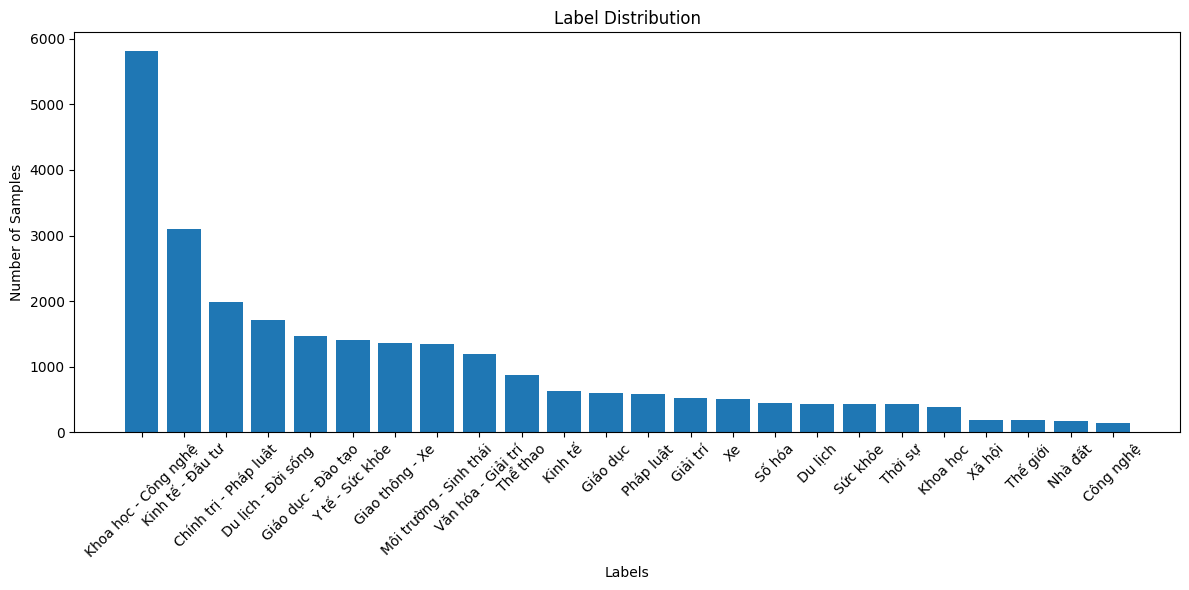

In [41]:
label_counter = Counter()

for labels in df["labels"]:
    label_counter.update(labels)

label_df = pd.DataFrame(
    label_counter.items(),
    columns=["Label", "Count"]
)

# Sắp xếp giảm dần
label_df = label_df.sort_values(
    by="Count",
    ascending=False
)

print(label_df)

# =========================
# VẼ BIỂU ĐỒ
# =========================

plt.figure(figsize=(12, 6))

plt.bar(
    label_df["Label"],
    label_df["Count"]
)

plt.title("Label Distribution")

plt.xlabel("Labels")

plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [42]:
df = df.drop(columns=["url"])
df

,title,content,labels,text
0,Nhiều người khiêng ôtô cứu nữ sinh mắc kẹt dướ...,"Khoảng 11h20, ông Đậu Thanh Thự, 58 tuổi, lái ...","[Y tế - Sức khỏe, Thời sự, Giao thông - Xe]",Nhiều người khiêng ôtô cứu nữ sinh mắc kẹt dướ...
1,Phó thủ tướng: Không thể tỉnh nào cũng làm sân...,Chủ trì cuộc họp chiều 7/5 về điều chỉnh Quy h...,"[Giao thông - Xe, Khoa học - Công nghệ, Du lịc...",Phó thủ tướng: Không thể tỉnh nào cũng làm sân...
2,Chuyên gia: Đừng để TP HCM tiếp tục 'đi xin' k...,"Tại hội thảo cấp quốc gia ""Luật đô thị đặc biệ...","[Giao thông - Xe, Khoa học - Công nghệ, Môi tr...",Chuyên gia: Đừng để TP HCM tiếp tục 'đi xin' k...
3,Chim hồng hoàng quý hiếm xuất hiện ở trung tâm...,"Khoảng 11h, nhiều nhân viên văn phòng khi đi q...","[Thời sự, Khoa học - Công nghệ, Môi trường - S...",Chim hồng hoàng quý hiếm xuất hiện ở trung tâm...
4,Quốc hội kiện toàn nhân sự nhiều ủy ban chuyên...,Chủ tịch Quốc hộiTrần Thanh Mẫnký nghị quyết p...,"[Khoa học - Công nghệ, Môi trường - Sinh thái,...",Quốc hội kiện toàn nhân sự nhiều ủy ban chuyên...
...,...,...,...,...
6238,Bộ Xây dựng đề xuất cơ chế đẩy nhanh quy hoạch...,Bộ Xây dựngvừa báo cáo Phó Thủ tướng Thường tr...,"[Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...",Bộ Xây dựng đề xuất cơ chế đẩy nhanh quy hoạch...
6239,Diễn biến giá chung cư trục đường Hoàng Hoa Th...,"Nhà đất, chung cư quanh trục đường sắt đô thị ...","[Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...",Diễn biến giá chung cư trục đường Hoàng Hoa Th...
6240,Quy hoạch cảng hàng không phải đồng bộ với quy...,Quy hoạch sân bay phải mang tầm nhìn dài hạn C...,"[Kinh tế - Đầu tư, Giao thông - Xe, Chính trị ...",Quy hoạch cảng hàng không phải đồng bộ với quy...
6241,"Thái Nguyên kiểm tra, yêu cầu xử lý triệt để ô...",Khu liên hợp xử lý chất thải Sông Công. (Nguồn...,"[Kinh tế - Đầu tư, Chính trị - Pháp luật, Khoa...","Thái Nguyên kiểm tra, yêu cầu xử lý triệt để ô..."


In [43]:
df.to_csv(
    "cleaned_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Done cleaning dataset!")
print("Total samples:", len(df))

Done cleaning dataset!
Total samples: 6243


In [45]:
from underthesea import word_tokenize
from transformers import AutoTokenizer

MODEL_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# =========================
# 12. TOKEN LENGTH ANALYSIS
# =========================

print("\nCalculating token lengths...")

token_lengths = []

for text in df["text"]:

    tokens = tokenizer.tokenize(str(text))

    token_lengths.append(len(tokens))


d:\NLP\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Calculating token lengths...


In [46]:
print("\n===== TOKEN STATISTICS =====")

print("Max length:",
      max(token_lengths))

print("Min length:",
      min(token_lengths))

print("Mean length:",
      np.mean(token_lengths))

print("Median length:",
      np.median(token_lengths))

print("90 percentile:",
      np.percentile(token_lengths, 90))

print("95 percentile:",
      np.percentile(token_lengths, 95))

print("99 percentile:",
      np.percentile(token_lengths, 99))


===== TOKEN STATISTICS =====
Max length: 5662
Min length: 94
Mean length: 839.3767419509851
Median length: 723.0
90 percentile: 1429.0
95 percentile: 1766.0
99 percentile: 2604.7999999999993


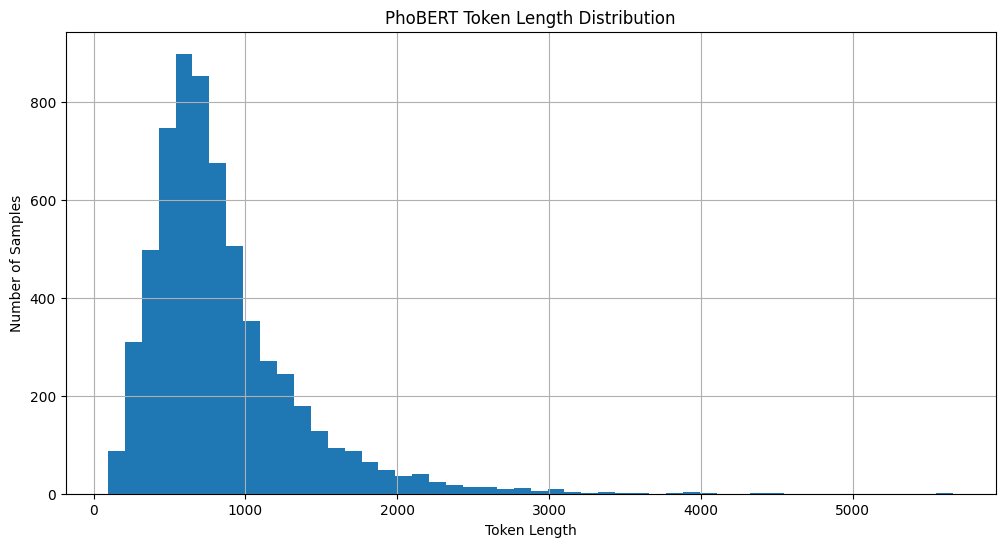

In [47]:
plt.figure(figsize=(12, 6))

plt.hist(
    token_lengths,
    bins=50
)

plt.xlabel("Token Length")

plt.ylabel("Number of Samples")

plt.title("PhoBERT Token Length Distribution")

plt.grid(True)

plt.show()

In [48]:
recommended_max_len = int(
    np.percentile(token_lengths, 95)
)

print("\nRecommended MAX_LEN:", recommended_max_len)



Recommended MAX_LEN: 1766
